In [1]:
import pandas as pd
import os

# Set the path to the data file
data_path = os.path.join('..', 'data', 'clean', 'EnrollmentsAUS_extracted.csv')

# Load the CSV file
df = pd.read_csv(data_path)

# Display the dataframe
df

,text
0,Selected Higher Education Statistics | Home\nV...
1,Selected Higher Education Statistics | Home\nV...
2,Selected Higher Education Statistics | Home\nV...
3,Selected Higher Education Statistics | Home\nV...
4,Selected Higher Education Statistics | Home\nV...
5,Selected Higher Education Statistics | Home\nV...
6,Selected Higher Education Statistics | Home\nV...
7,Selected Higher Education Statistics | Home\nV...
8,Selected Higher Education Statistics | Home\nV...
9,Selected Higher Education Statistics | Home\nV...


In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd

driver = webdriver.Chrome()
driver.get('https://app.powerbi.com/view?r=eyJrIjoiN2Y1ZTM1Y2YtYzYxNC00MWI0LWFhNTktYTI3NWU2OWI3NGFkIiwidCI6ImRkMGNmZDE1LTQ1NTgtNGIxMi04YmFkLWVhMjY5ODRmYzQxNyJ9')

# Wait for table to load, then extract
table = driver.find_element(By.TAG_NAME, 'table')
df = pd.read_html(table.get_attribute('outerHTML'))[0]
print(df)

driver.quit()

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"tag name","selector":"table"}
  (Session info: chrome=146.0.7680.155); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff619d029c5+2ed785]
	chromedriver!GetHandleVerifier [0x7ff619a2a0d0+14e90]
	chromedriver!(No symbol) [0x7ff61978db2d]
	chromedriver!(No symbol) [0x7ff6197e6b9e]
	chromedriver!(No symbol) [0x7ff6197e6eac]
	chromedriver!(No symbol) [0x7ff619836fe7]
	chromedriver!(No symbol) [0x7ff619833b9b]
	chromedriver!(No symbol) [0x7ff6197d9298]
	chromedriver!(No symbol) [0x7ff6197da183]
	chromedriver!GetHandleVerifier [0x7ff619d2de0d+318bcd]
	chromedriver!GetHandleVerifier [0x7ff619d28588+313348]
	chromedriver!GetHandleVerifier [0x7ff619d49d7a+334b3a]
	chromedriver!GetHandleVerifier [0x7ff619a46785+31545]
	chromedriver!GetHandleVerifier [0x7ff619a4facc+3a88c

In [4]:
# Display the scraped data as a formatted table
from IPython.display import display
import pandas as pd

# Show the scraped data
print("Enrollment Data from PowerBI:")
display(df)

Enrollment Data from PowerBI:


,text
0,Selected Higher Education Statistics | Home\nV...
1,Selected Higher Education Statistics | Home\nV...
2,Selected Higher Education Statistics | Home\nV...
3,Selected Higher Education Statistics | Home\nV...
4,Selected Higher Education Statistics | Home\nV...
5,Selected Higher Education Statistics | Home\nV...
6,Selected Higher Education Statistics | Home\nV...
7,Selected Higher Education Statistics | Home\nV...
8,Selected Higher Education Statistics | Home\nV...
9,Selected Higher Education Statistics | Home\nV...


In [3]:
# Save to CSV
df.to_csv('../data/clean/EnrollmentsAUS_scraped.csv', index=False)

In [5]:
import os
import pandas as pd
from IPython.display import display

attached_data_path = os.path.join('..', 'data', 'raw', 'EnrollmentsAUS_attached.csv')
attached_df = pd.read_csv(attached_data_path)

display(attached_df)

,Category,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Postgraduate (Research),65010,66145,66455,66578,66337,64895,67198,66580,66503
1,Postgraduate (Other),348848,361540,390390,420199,430311,416823,400384,458521,508045
2,Bachelor,970932,971664,992089,1005614,1007034,1016411,981833,966588,984225
3,Sub-Bachelor,66503,65709,65845,67256,71077,68936,68506,73178,78443
4,Enabling,28500,28901,28389,30752,32634,25659,21211,19396,20998
5,Non-award/Microcredentials,15416,19424,19352,19399,15474,9849,12279,16300,17863
6,Total,1495209,1513383,1562520,1609798,1622867,1602573,1551411,1600563,1676077


In [10]:
import os
import pandas as pd
from IPython.display import display

broad_field_data_path = os.path.join('..', 'data', 'raw', 'EnrollmentsAUS_broad_field_attached.csv')

candidate_paths = [
	broad_field_data_path,
	os.path.join('..', 'data', 'clean', 'EnrollmentsAUS_broad_field_attached.csv'),
	attached_data_path,  # fallback to existing file already loaded in this notebook
]

existing_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if existing_path is None:
	raise FileNotFoundError(
		f"Could not find any expected input file. Checked: {candidate_paths}"
	)

broad_field_df = pd.read_csv(existing_path)
print(f"Loaded file: {existing_path}")

display(broad_field_df)

Loaded file: ..\data\raw\EnrollmentsAUS_attached.csv


,Category,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Postgraduate (Research),65010,66145,66455,66578,66337,64895,67198,66580,66503
1,Postgraduate (Other),348848,361540,390390,420199,430311,416823,400384,458521,508045
2,Bachelor,970932,971664,992089,1005614,1007034,1016411,981833,966588,984225
3,Sub-Bachelor,66503,65709,65845,67256,71077,68936,68506,73178,78443
4,Enabling,28500,28901,28389,30752,32634,25659,21211,19396,20998
5,Non-award/Microcredentials,15416,19424,19352,19399,15474,9849,12279,16300,17863
6,Total,1495209,1513383,1562520,1609798,1622867,1602573,1551411,1600563,1676077


In [7]:
import os
import pandas as pd
from IPython.display import display

comparison_data_path = os.path.join('..', 'rates', 'allocation_of_units_of_study_year_comparison.csv')
comparison_df = pd.read_csv(comparison_data_path)

print(f"Rows: {len(comparison_df)}, Columns: {len(comparison_df.columns)}")
display(comparison_df)

Rows: 859, Columns: 51


,foe_code,detailed_discipline_title,detailed_discipline,narrow_discipline,broad_discipline,special_course_type_code,maximum_student_contribution_indicator,commonwealth_contribution_2019,commonwealth_contribution_2020,commonwealth_contribution_2021,...,grandfathered_maximum_student_contribution_2025,grandfathered_maximum_student_contribution_2026,maximum_student_contribution_2019,maximum_student_contribution_2020,maximum_student_contribution_2021,maximum_student_contribution_2022,maximum_student_contribution_2023,maximum_student_contribution_2024,maximum_student_contribution_2025,maximum_student_contribution_2026
0,10100.0,Mathematical Sciences,010100 - Mathematical Sciences,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value,Any E392 value,NaN,NaN,13250.0,...,4627.0,4738.0,NaN,NaN,3950.0,3985.0,4124.0,4445.0,4627.0,4738.0
1,10100.0,Mathematical Sciences,010100 - Mathematical Sciences,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Not E312=27,Not E392=8,10630.0,10821.0,NaN,...,NaN,NaN,9359.0,9527.0,NaN,NaN,NaN,NaN,NaN,NaN
2,10101.0,Mathematics,010101 - Mathematics,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value,Any E392 value,NaN,NaN,13250.0,...,4627.0,4738.0,NaN,NaN,3950.0,3985.0,4124.0,4445.0,4627.0,4738.0
3,10101.0,Mathematics,010101 - Mathematics,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Not E312=27,Not E392=8,10630.0,10821.0,NaN,...,NaN,NaN,9359.0,9527.0,NaN,NaN,NaN,NaN,NaN,NaN
4,10103.0,Statistics,010103 - Statistics,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value,Any E392 value,NaN,NaN,13250.0,...,4627.0,4738.0,NaN,NaN,3950.0,3985.0,4124.0,4445.0,4627.0,4738.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854,120599.0,"Employment Skills Programs, n.e.c.","120599 - Employment Skills Programs, n.e.c.",1205-Employment Skills Programs,12 - MIXED FIELD PROGRAMMES,Any E312 value,Any E392 value,NaN,NaN,1100.0,...,13305.0,13624.0,NaN,NaN,14500.0,14630.0,15142.0,16323.0,16992.0,17399.0
855,129900.0,Other Mixed Field Programmes,129900 - Other Mixed Field Programmes,1299 - Other Mixed Field Programmes,12 - MIXED FIELD PROGRAMMES,Any E312 value,Any E392 value,NaN,NaN,1100.0,...,13305.0,13624.0,NaN,NaN,14500.0,14630.0,15142.0,16323.0,16992.0,17399.0
856,129900.0,Other Mixed Field Programmes,129900 - Other Mixed Field Programmes,1299 - Other Mixed Field Programmes,12 - MIXED FIELD PROGRAMMES,Not E312=27,Not E392=8,2160.0,2198.0,NaN,...,NaN,NaN,10958.0,11155.0,NaN,NaN,NaN,NaN,NaN,NaN
857,129999.0,"Mixed Field Programmes, n.e.c.","129999 - Mixed Field Programmes, n.e.c.",1299 - Other Mixed Field Programmes,12 - MIXED FIELD PROGRAMMES,Any E312 value,Any E392 value,NaN,NaN,1100.0,...,13305.0,13624.0,NaN,NaN,14500.0,14630.0,15142.0,16323.0,16992.0,17399.0


In [8]:
import os
import pandas as pd
from IPython.display import display

comparison_by_foe_path = os.path.join('..', 'rates', 'allocation_of_units_of_study_year_comparison_by_foe_code.csv')
comparison_by_foe_df = pd.read_csv(comparison_by_foe_path)

print(f"Rows: {len(comparison_by_foe_df)}, Columns: {len(comparison_by_foe_df.columns)}")
display(comparison_by_foe_df)

Rows: 427, Columns: 51


,foe_code,detailed_discipline_title,detailed_discipline,narrow_discipline,broad_discipline,special_course_type_code,maximum_student_contribution_indicator,commonwealth_contribution_2019,commonwealth_contribution_2020,commonwealth_contribution_2021,...,grandfathered_maximum_student_contribution_2025,grandfathered_maximum_student_contribution_2026,maximum_student_contribution_2019,maximum_student_contribution_2020,maximum_student_contribution_2021,maximum_student_contribution_2022,maximum_student_contribution_2023,maximum_student_contribution_2024,maximum_student_contribution_2025,maximum_student_contribution_2026
0,10100.0,Mathematical Sciences,010100 - Mathematical Sciences,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value | Not E312=27,Any E392 value | Not E392=8,10630.0,10821.0,13250.0,...,4627.0,4738.0,9359.0,9527.0,3950.0,3985.0,4124.0,4445.0,4627.0,4738.0
1,10101.0,Mathematics,010101 - Mathematics,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value | Not E312=27,Any E392 value | Not E392=8,10630.0,10821.0,13250.0,...,4627.0,4738.0,9359.0,9527.0,3950.0,3985.0,4124.0,4445.0,4627.0,4738.0
2,10103.0,Statistics,010103 - Statistics,0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value | Not E312=27,Any E392 value | Not E392=8,10630.0,10821.0,13250.0,...,4627.0,4738.0,9359.0,9527.0,3950.0,3985.0,4124.0,4445.0,4627.0,4738.0
3,10199.0,"Mathematical Sciences, n.e.c.","010199 - Mathematical Sciences, n.e.c.",0101 - Mathematical Sciences,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value | Not E312=27,Any E392 value | Not E392=8,10630.0,10821.0,13250.0,...,4627.0,4738.0,9359.0,9527.0,3950.0,3985.0,4124.0,4445.0,4627.0,4738.0
4,10300.0,Physics and Astronomy,010300 - Physics and Astronomy,0103 - Physics and Astronomy,01 - NATURAL AND PHYSICAL SCIENCES,Any E312 value | Not E312=27,Any E392 value | Not E392=8,18586.0,18920.0,16250.0,...,9314.0,9537.0,9359.0,9527.0,7950.0,8021.0,8301.0,8948.0,9314.0,9537.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,120503.0,Job Search Skills Programs,120503 - Job Search Skills Programs,1205-Employment Skills Programs,12 - MIXED FIELD PROGRAMMES,Any E312 value,Any E392 value,NaN,NaN,1100.0,...,13305.0,13624.0,NaN,NaN,14500.0,14630.0,15142.0,16323.0,16992.0,17399.0
423,120505.0,Work Practices Programs,120505 - Work Practices Programs,1205-Employment Skills Programs,12 - MIXED FIELD PROGRAMMES,Any E312 value,Any E392 value,NaN,NaN,1100.0,...,13305.0,13624.0,NaN,NaN,14500.0,14630.0,15142.0,16323.0,16992.0,17399.0
424,120599.0,"Employment Skills Programs, n.e.c.","120599 - Employment Skills Programs, n.e.c.",1205-Employment Skills Programs,12 - MIXED FIELD PROGRAMMES,Any E312 value,Any E392 value,NaN,NaN,1100.0,...,13305.0,13624.0,NaN,NaN,14500.0,14630.0,15142.0,16323.0,16992.0,17399.0
425,129900.0,Other Mixed Field Programmes,129900 - Other Mixed Field Programmes,1299 - Other Mixed Field Programmes,12 - MIXED FIELD PROGRAMMES,Any E312 value | Not E312=27,Any E392 value | Not E392=8,2160.0,2198.0,1100.0,...,13305.0,13624.0,10958.0,11155.0,14500.0,14630.0,15142.0,16323.0,16992.0,17399.0


In [1]:
from pathlib import Path

import pandas as pd



file_path = Path.cwd().parent / "EmploymentOutcomes" / "higher_education_work_and_occupation.xlsx"

if not file_path.exists():

    file_path = Path.cwd() / "EmploymentOutcomes" / "higher_education_work_and_occupation.xlsx"



xls = pd.ExcelFile(file_path)

print("Sheets:", xls.sheet_names)



for sheet in xls.sheet_names:

    df_preview = pd.read_excel(file_path, sheet_name=sheet)

    print(f"\nSheet: {sheet} | shape={df_preview.shape}")

    print("Columns:")

    for c in df_preview.columns:

        print("-", c)

    display(df_preview.head(5))


Sheets: ['Contents', 'Data_Dictionary', 'Table_1', 'Table_2', 'Table_3']

Sheet: Contents | shape=(48, 3)
Columns:
- Unnamed: 0
- Unnamed: 1
- Unnamed: 2


,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,Higher Education - work status and occupation,NaN,NaN
4,NaN,NaN,NaN



Sheet: Data_Dictionary | shape=(42, 8)
Columns:
- Unnamed: 0
- Unnamed: 1
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4
- Unnamed: 5
- Unnamed: 6
- Unnamed: 7


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Back to Contents
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data dictionary,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Sheet: Table_1 | shape=(198, 17)
Columns:
- Unnamed: 0
- Unnamed: 1
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4
- Unnamed: 5
- Unnamed: 6
- Unnamed: 7
- Unnamed: 8
- Unnamed: 9
- Unnamed: 10
- Unnamed: 11
- Unnamed: 12
- Unnamed: 13
- Unnamed: 14
- Unnamed: 15
- Unnamed: 16


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Back to Contents
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Table 2 - Wage and salary work by fields of ed...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Sheet: Table_2 | shape=(121, 17)
Columns:
- Unnamed: 0
- Unnamed: 1
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4
- Unnamed: 5
- Unnamed: 6
- Unnamed: 7
- Unnamed: 8
- Unnamed: 9
- Unnamed: 10
- Unnamed: 11
- Unnamed: 12
- Unnamed: 13
- Unnamed: 14
- Unnamed: 15
- Unnamed: 16


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Back to Contents
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Table 2 - Wage and salary work by fields and l...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Sheet: Table_3 | shape=(7123, 24)
Columns:
- Unnamed: 0
- Unnamed: 1
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4
- Unnamed: 5
- Unnamed: 6
- Unnamed: 7
- Unnamed: 8
- Unnamed: 9
- Unnamed: 10
- Unnamed: 11
- Unnamed: 12
- Unnamed: 13
- Unnamed: 14
- Unnamed: 15
- Unnamed: 16
- Unnamed: 17
- Unnamed: 18
- Unnamed: 19
- Unnamed: 20
- Unnamed: 21
- Unnamed: 22
- Unnamed: 23


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Back to Contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Table 2 - Occupations by fields and levels of ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Diagnose Table_1 structure to locate field, employment-rate, and wage columns

raw_t1 = pd.read_excel(file_path, sheet_name="Table_1", header=None)



for i in range(0, 70):

    row_text = " | ".join([str(x) for x in raw_t1.iloc[i].tolist()])

    if any(k in row_text.lower() for k in ["field", "education", "employment", "wage", "salary", "rate"]):

        print(i, row_text)


4 Table 2 - Wage and salary work by fields of education | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan
6 FOE_BROAD | FOE_NARROW | FOE_DETAILED | COUNT_FOE | COUNT_1_WAGE_SALARY_WORK | WAGE_SALARY_WORK_PCT_1 | COUNT_3_WAGE_SALARY_WORK | WAGE_SALARY_WORK_PCT_3 | COUNT_5_WAGE_SALARY_WORK | WAGE_SALARY_WORK_PCT_5 | nan | nan | nan | nan | nan | nan | nan
41 Education | Curriculum and Education Studies | Curriculum and Education Studies | 1765 | 1640 | 95.6 | 1620 | 95.6 | 1605 | 95 | nan | nan | nan | nan | nan | nan | nan
42 Education | Curriculum and Education Studies | Education Studies | 6175 | 5600 | 94.7 | 5530 | 93.6 | 5445 | 93.3 | nan | nan | nan | nan | nan | nan | nan
43 Education | Education | Education | 1270 | 1175 | 95.1 | 1160 | 93.9 | 1130 | 93 | nan | nan | nan | nan | nan | nan | nan
44 Education | Other Education | Education, n.e.c. | 2965 | 2625 | 92.9 | 2560 | 91.6 | 2520 | 91 | nan | nan | nan | nan | nan | nan | nan
4

In [3]:
# Diagnose Table_2 and Table_3 structure

for sheet in ["Table_2", "Table_3"]:

    raw = pd.read_excel(file_path, sheet_name=sheet, header=None)

    print(f"\n=== {sheet} ===")

    for i in range(0, 80):

        row_text = " | ".join([str(x) for x in raw.iloc[i].tolist()])

        if any(k in row_text.lower() for k in ["foe", "field", "education", "employment", "wage", "salary", "rate", "occupation"]):

            print(i, row_text)



=== Table_2 ===
4 Table 2 - Wage and salary work by fields and levels of education | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan | nan
6 COURSE_TYPE_BROAD | FOE_BROAD | FOE_NARROW | COUNT_LOE_FOE | COUNT_1_WAGE_SALARY_WORK | WAGE_SALARY_WORK_PCT_1 | COUNT_3_WAGE_SALARY_WORK | WAGE_SALARY_WORK_PCT_3 | COUNT_5_WAGE_SALARY_WORK | WAGE_SALARY_WORK_PCT_5 | nan | nan | nan | nan | nan | nan | nan
17 Post-graduate | Education | Curriculum and Education Studies | 7365 | 6730 | 94.9 | 6655 | 94.4 | 6545 | 93.7 | nan | nan | nan | nan | nan | nan | nan
18 Post-graduate | Education | Other Education | 4375 | 3920 | 93.4 | 3845 | 92.9 | 3765 | 91.7 | nan | nan | nan | nan | nan | nan | nan
19 Post-graduate | Education | Teacher Education | 67980 | 64245 | 96.3 | 62950 | 94.9 | 62085 | 94.4 | nan | nan | nan | nan | nan | nan | nan
41 Post-graduate | Management and Commerce | Banking, Finance and Related Fields | 4640 | 3870 | 89.7 | 3745 | 87.9 | 3680 |

In [4]:
# Quick workbook-wide keyword scan

for sheet in ["Table_1", "Table_2", "Table_3"]:

    raw = pd.read_excel(file_path, sheet_name=sheet, header=None, dtype=str)

    text = "\n".join(raw.fillna("").astype(str).agg(" ".join, axis=1).tolist()).lower()

    print(

        sheet,

        "| has 'employment':", "employment" in text,

        "| has 'wage':", "wage" in text,

        "| has 'salary':", "salary" in text,

        "| has 'rate':", "rate" in text,

    )


Table_1 | has 'employment': False | has 'wage': True | has 'salary': True | has 'rate': False
Table_2 | has 'employment': False | has 'wage': True | has 'salary': True | has 'rate': False
Table_3 | has 'employment': False | has 'wage': False | has 'salary': False | has 'rate': True


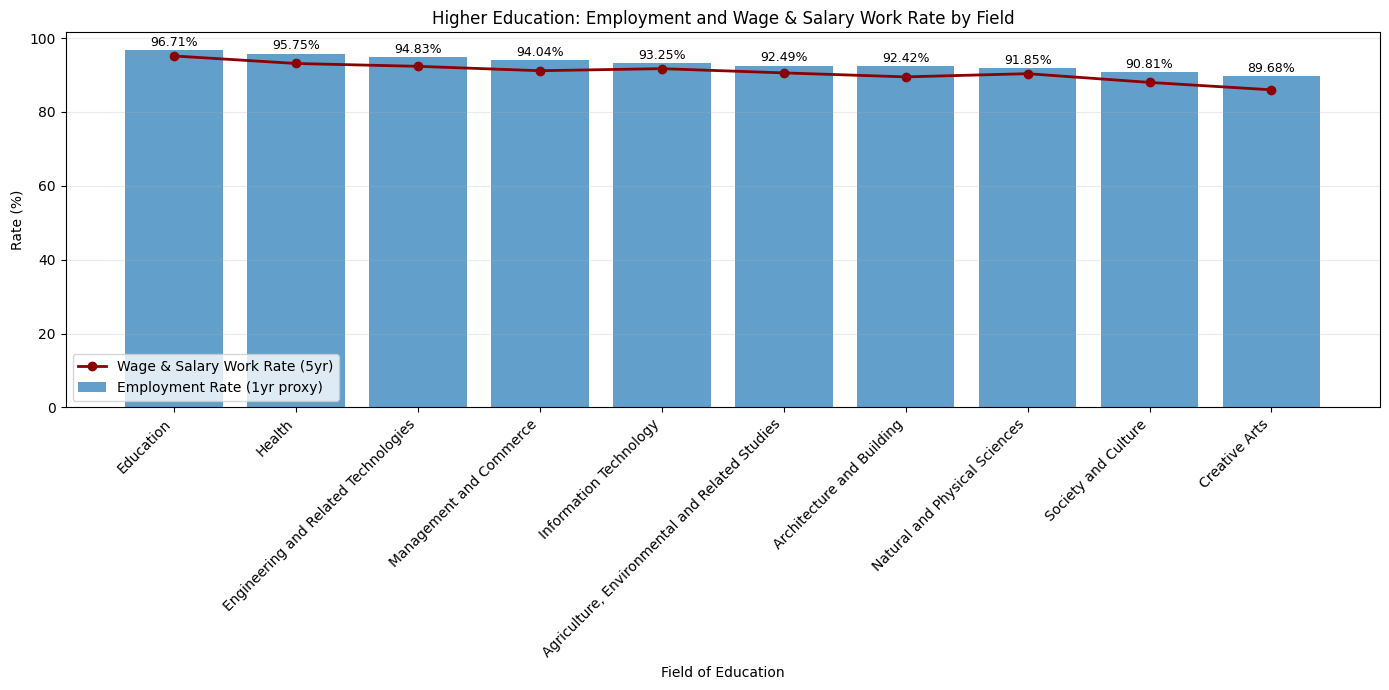

Note: This workbook does not expose a literal 'employment rate'/'wage rate' pair.
Graph uses WAGE_SALARY_WORK_PCT_1 as employment-rate proxy and WAGE_SALARY_WORK_PCT_5 as wage & salary work-rate (5yr).


,Field,EmploymentRate,WageSalaryWorkRate
3,Education,96.713856,95.150318
5,Health,95.751467,93.116841
4,Engineering and Related Technologies,94.830083,92.346710
7,Management and Commerce,94.036597,91.163990
6,Information Technology,93.247184,91.719897
0,"Agriculture, Environmental and Related Studies",92.493839,90.571751
1,Architecture and Building,92.416652,89.493935
8,Natural and Physical Sciences,91.851381,90.358966
9,Society and Culture,90.810789,87.994472
2,Creative Arts,89.677531,85.990527


In [6]:
# Graph by field: employment-rate proxy vs wage/salary work-rate proxy

import matplotlib.pyplot as plt



# Table_1 has header on row 6 (0-indexed in raw scan)

field_df = pd.read_excel(file_path, sheet_name="Table_1", header=6)

field_df = field_df.dropna(how="all")



# Keep only rows with field names

field_df = field_df[field_df["FOE_BROAD"].notna()].copy()

field_df = field_df[~field_df["FOE_BROAD"].astype(str).str.contains("FOE_BROAD", na=False)]



# Numeric conversion

for col in ["COUNT_FOE", "WAGE_SALARY_WORK_PCT_1", "WAGE_SALARY_WORK_PCT_5"]:

    field_df[col] = pd.to_numeric(field_df[col], errors="coerce")



# Aggregate to broad field level (weighted by COUNT_FOE)

def weighted_avg(values, weights):

    valid = values.notna() & weights.notna() & (weights > 0)

    if valid.sum() == 0:

        return pd.NA

    return (values[valid] * weights[valid]).sum() / weights[valid].sum()



rows = []

for field, group in field_df.groupby("FOE_BROAD"):

    weight = group["COUNT_FOE"]

    emp_rate = weighted_avg(group["WAGE_SALARY_WORK_PCT_1"], weight)

    wage_rate = weighted_avg(group["WAGE_SALARY_WORK_PCT_5"], weight)

    rows.append({

        "Field": field,

        "EmploymentRate": emp_rate,

        "WageSalaryWorkRate": wage_rate,

    })



field_rates = pd.DataFrame(rows).dropna().sort_values("EmploymentRate", ascending=False)



plt.figure(figsize=(14, 7))

ax = plt.gca()

bars = ax.bar(field_rates["Field"], field_rates["EmploymentRate"], alpha=0.7, label="Employment Rate (1yr proxy)")

ax.plot(

    field_rates["Field"],

    field_rates["WageSalaryWorkRate"],

    marker="o",

    linewidth=2,

    color="darkred",

    label="Wage & Salary Work Rate (5yr)",

)



# Add exact employment-rate labels on bars

for bar, value in zip(bars, field_rates["EmploymentRate"]):

    ax.text(

        bar.get_x() + bar.get_width() / 2,

        bar.get_height() + 0.4,

        f"{value:.2f}%",

        ha="center",

        va="bottom",

        fontsize=9,

    )



ax.set_title("Higher Education: Employment and Wage & Salary Work Rate by Field")

ax.set_ylabel("Rate (%)")

ax.set_xlabel("Field of Education")

plt.xticks(rotation=45, ha="right")

ax.legend()

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.show()



print("Note: This workbook does not expose a literal 'employment rate'/'wage rate' pair.")

print("Graph uses WAGE_SALARY_WORK_PCT_1 as employment-rate proxy and WAGE_SALARY_WORK_PCT_5 as wage & salary work-rate (5yr).")

display(field_rates)


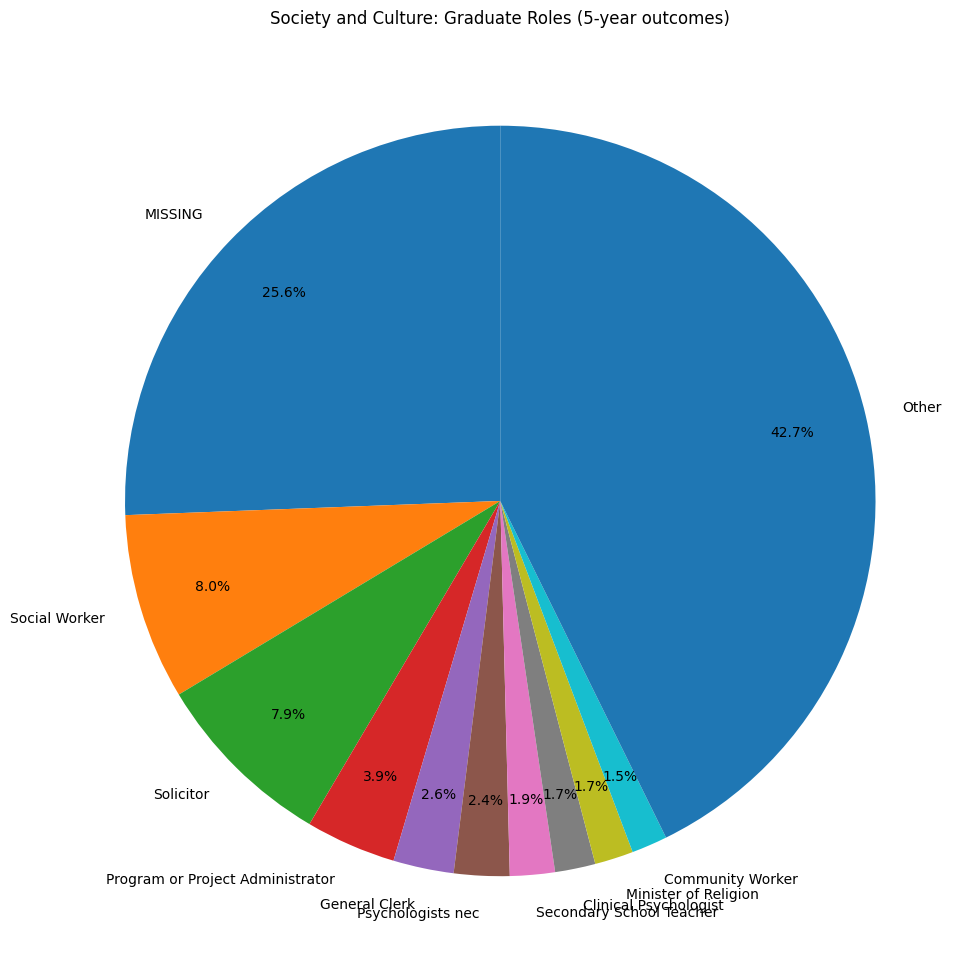

,OCC_5YR,OCC_COUNT_5
133,MISSING,34170
227,Social Worker,10710
228,Solicitor,10520
183,Program or Project Administrator,5200
89,General Clerk,3480
186,Psychologists nec,3190
221,Secondary School Teacher,2580
36,Clinical Psychologist,2320
147,Minister of Religion,2220
41,Community Worker,2060


In [7]:
# Pie chart: Society and Culture graduate roles (5-year outcomes)

import matplotlib.pyplot as plt

import pandas as pd



occ_df = pd.read_excel(file_path, sheet_name="Table_3", header=6)

occ_df = occ_df.dropna(how="all")



# Keep Society and Culture rows and valid role/count values

soc_df = occ_df[occ_df["FOE_BROAD"].astype(str).str.strip().str.upper() == "SOCIETY AND CULTURE"].copy()

soc_df["OCC_5YR"] = soc_df["OCC_5YR"].astype(str).str.strip()

soc_df["OCC_COUNT_5"] = pd.to_numeric(soc_df["OCC_COUNT_5"], errors="coerce")

soc_df = soc_df[soc_df["OCC_5YR"].notna() & (soc_df["OCC_5YR"] != "") & soc_df["OCC_COUNT_5"].notna()]



# Aggregate role counts

role_counts = soc_df.groupby("OCC_5YR", as_index=False)["OCC_COUNT_5"].sum()

role_counts = role_counts.sort_values("OCC_COUNT_5", ascending=False)



# Keep pie readable: top 10 roles + Other

top_n = 10

top_roles = role_counts.head(top_n).copy()

other_count = role_counts.iloc[top_n:]["OCC_COUNT_5"].sum()

if other_count > 0:

    top_roles = pd.concat([

        top_roles,

        pd.DataFrame({"OCC_5YR": ["Other"], "OCC_COUNT_5": [other_count]})

    ], ignore_index=True)



plt.figure(figsize=(10, 10))

plt.pie(

    top_roles["OCC_COUNT_5"],

    labels=top_roles["OCC_5YR"],

    autopct="%1.1f%%",

    startangle=90,

    pctdistance=0.8,

)

plt.title("Society and Culture: Graduate Roles (5-year outcomes)")

plt.tight_layout()

plt.show()



display(role_counts.head(20))


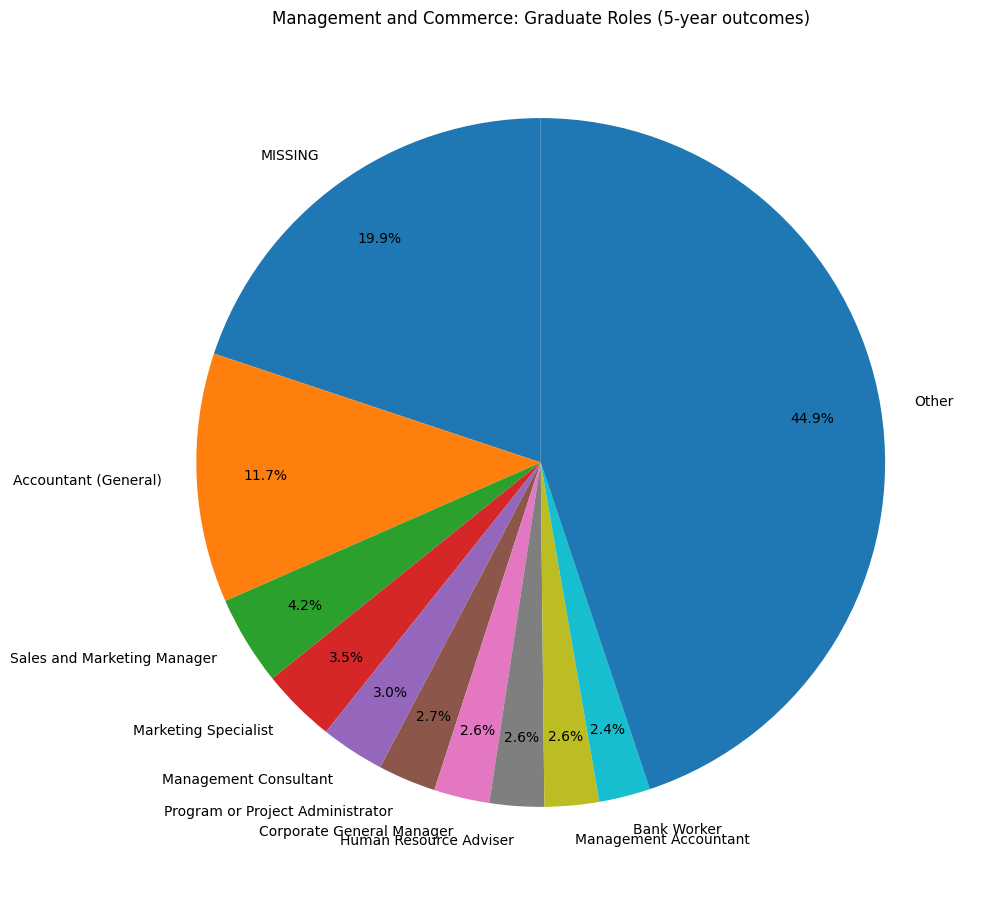

,OCC_5YR,OCC_COUNT_5
146,MISSING,34790
0,Accountant (General),20480
242,Sales and Marketing Manager,7350
152,Marketing Specialist,6130
149,Management Consultant,5240
201,Program or Project Administrator,4760
51,Corporate General Manager,4570
118,Human Resource Adviser,4470
148,Management Accountant,4470
15,Bank Worker,4210


In [8]:
# Pie chart: Management and Commerce graduate roles (5-year outcomes)

import matplotlib.pyplot as plt

import pandas as pd



occ_df = pd.read_excel(file_path, sheet_name="Table_3", header=6)

occ_df = occ_df.dropna(how="all")



# Keep Management and Commerce rows and valid role/count values

mc_df = occ_df[occ_df["FOE_BROAD"].astype(str).str.strip().str.upper() == "MANAGEMENT AND COMMERCE"].copy()

mc_df["OCC_5YR"] = mc_df["OCC_5YR"].astype(str).str.strip()

mc_df["OCC_COUNT_5"] = pd.to_numeric(mc_df["OCC_COUNT_5"], errors="coerce")

mc_df = mc_df[mc_df["OCC_5YR"].notna() & (mc_df["OCC_5YR"] != "") & mc_df["OCC_COUNT_5"].notna()]



# Aggregate role counts

mc_role_counts = mc_df.groupby("OCC_5YR", as_index=False)["OCC_COUNT_5"].sum()

mc_role_counts = mc_role_counts.sort_values("OCC_COUNT_5", ascending=False)



# Keep pie readable: top 10 roles + Other

top_n = 10

mc_top_roles = mc_role_counts.head(top_n).copy()

mc_other_count = mc_role_counts.iloc[top_n:]["OCC_COUNT_5"].sum()

if mc_other_count > 0:

    mc_top_roles = pd.concat([

        mc_top_roles,

        pd.DataFrame({"OCC_5YR": ["Other"], "OCC_COUNT_5": [mc_other_count]})

    ], ignore_index=True)



plt.figure(figsize=(10, 10))

plt.pie(

    mc_top_roles["OCC_COUNT_5"],

    labels=mc_top_roles["OCC_5YR"],

    autopct="%1.1f%%",

    startangle=90,

    pctdistance=0.8,

)

plt.title("Management and Commerce: Graduate Roles (5-year outcomes)")

plt.tight_layout()

plt.show()



display(mc_role_counts.head(20))


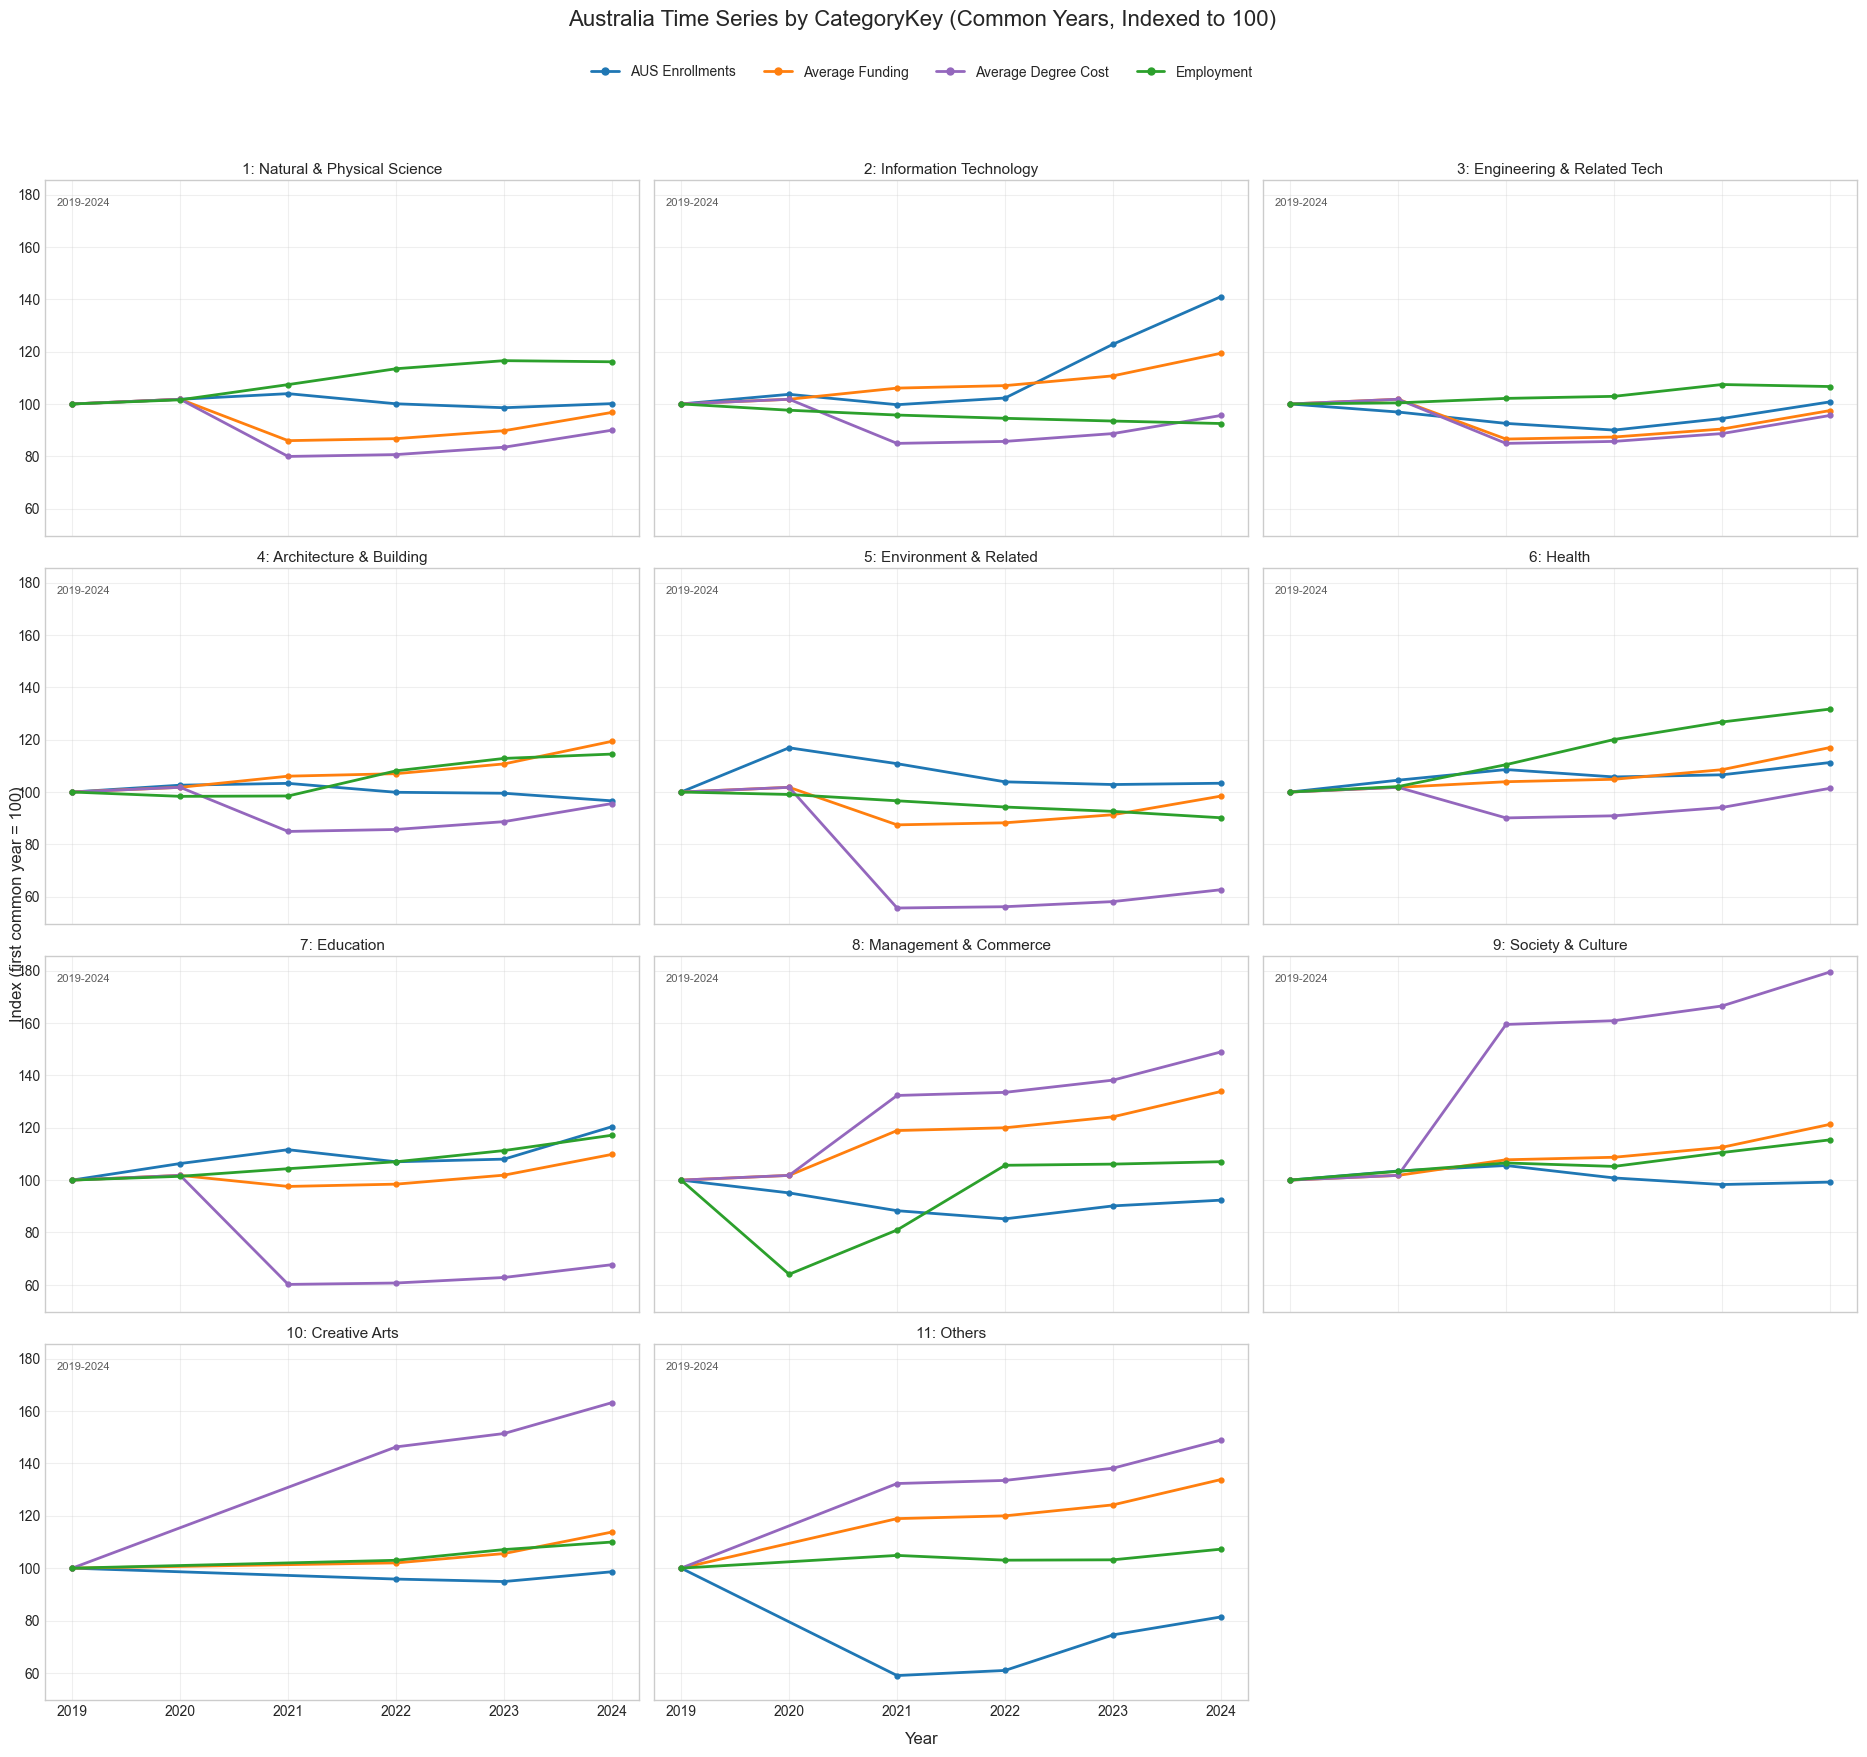

,CategoryKey,Year,Value,Series,BaseValue,Index100
0,1,2019,1.343340e+05,AUS Enrollments,1.343340e+05,100.000000
1,1,2020,1.367330e+05,AUS Enrollments,1.343340e+05,101.785847
2,1,2021,1.396290e+05,AUS Enrollments,1.343340e+05,103.941668
3,1,2022,1.344240e+05,AUS Enrollments,1.343340e+05,100.066997
4,1,2023,1.324060e+05,AUS Enrollments,1.343340e+05,98.564771
5,1,2024,1.345110e+05,AUS Enrollments,1.343340e+05,100.131761
12,1,2019,9.402216e+03,Average Degree Cost,9.402216e+03,100.000000
13,1,2020,9.571000e+03,Average Degree Cost,9.402216e+03,101.795149
14,1,2021,7.517568e+03,Average Degree Cost,9.402216e+03,79.955272
15,1,2022,7.584676e+03,Average Degree Cost,9.402216e+03,80.669020


In [13]:
# Time series by CategoryKey: AUS Enrollments, Average Funding, Average Degree Cost, Employment (clean presentation)
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- Paths ----------
base_candidates = [Path.cwd(), Path.cwd().parent]
clean_dir = next((p / "data" / "clean" for p in base_candidates if (p / "data" / "clean").exists()), None)
if clean_dir is None:
    raise FileNotFoundError("Could not locate data/clean directory")

enroll_path = clean_dir / "EnrollmentsAUS_category_with_numeric_key.csv"
funding_path = clean_dir / "AnnualFundingAUS2019-2026_with_category_key.csv"
employment_path = clean_dir / "employment_by_industry_20y+keys.csv"

for p in [enroll_path, funding_path, employment_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# ---------- Helpers ----------
def find_col(columns, candidates):
    lower_map = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

category_names = {
    1: "Natural & Physical Science",
    2: "Information Technology",
    3: "Engineering & Related Tech",
    4: "Architecture & Building",
    5: "Environment & Related",
    6: "Health",
    7: "Education",
    8: "Management & Commerce",
    9: "Society & Culture",
    10: "Creative Arts",
    11: "Others",
    99: "Total",
}

# ---------- 1) AUS Enrollments aggregate ----------
enroll_df = pd.read_csv(enroll_path)
enroll_key_col = find_col(enroll_df.columns, ["CategoryKey", "categorykey", "category_key"])
if enroll_key_col is None:
    raise ValueError("Could not find CategoryKey column in AUS enrollments file")

enroll_year_cols = [c for c in enroll_df.columns if re.fullmatch(r"\d{4}", str(c).strip())]
if not enroll_year_cols:
    raise ValueError("No year columns found in AUS enrollments file")

enroll_long = enroll_df[[enroll_key_col] + enroll_year_cols].melt(
    id_vars=[enroll_key_col], var_name="Year", value_name="AUSEnrollments"
)
enroll_long["CategoryKey"] = pd.to_numeric(enroll_long[enroll_key_col], errors="coerce")
enroll_long["Year"] = pd.to_numeric(enroll_long["Year"], errors="coerce")
enroll_long["AUSEnrollments"] = pd.to_numeric(enroll_long["AUSEnrollments"], errors="coerce")
aus_enroll_agg = (
    enroll_long.dropna(subset=["CategoryKey", "Year", "AUSEnrollments"])
    .groupby(["CategoryKey", "Year"], as_index=False)["AUSEnrollments"]
    .sum()
)

# ---------- 2) AUS funding aggregates ----------
fund_df = pd.read_csv(funding_path)
fund_key_col = find_col(fund_df.columns, ["CategoryKey", "categorykey", "category_key"])
fund_year_col = find_col(fund_df.columns, ["Year", "year"])
if fund_key_col is None or fund_year_col is None:
    raise ValueError("Could not find CategoryKey/Year columns in funding file")

commonwealth_col = next((c for c in fund_df.columns if "commonwealth" in str(c).lower()), None)
student_col = next((c for c in fund_df.columns if "maximum" in str(c).lower() and "student" in str(c).lower()), None)
if student_col is None:
    student_col = next((c for c in fund_df.columns if "student" in str(c).lower() and "contribution" in str(c).lower()), None)

if commonwealth_col is None and student_col is None:
    raise ValueError("Could not detect funding/cost columns in funding file")

fund_df["CategoryKey"] = pd.to_numeric(fund_df[fund_key_col], errors="coerce")
fund_df["Year"] = pd.to_numeric(fund_df[fund_year_col], errors="coerce")

if commonwealth_col is not None:
    fund_df["CommonwealthValue"] = pd.to_numeric(fund_df[commonwealth_col], errors="coerce")
else:
    fund_df["CommonwealthValue"] = np.nan

if student_col is not None:
    fund_df["DegreeCostValue"] = pd.to_numeric(fund_df[student_col], errors="coerce")
else:
    fund_df["DegreeCostValue"] = np.nan

fund_df["FundingTotalValue"] = fund_df[["CommonwealthValue", "DegreeCostValue"]].sum(axis=1, min_count=1)

avg_funding_agg = (
    fund_df.dropna(subset=["CategoryKey", "Year", "FundingTotalValue"])
    .groupby(["CategoryKey", "Year"], as_index=False)["FundingTotalValue"]
    .mean()
    .rename(columns={"FundingTotalValue": "AverageFunding"})
)

avg_degree_cost_agg = (
    fund_df.dropna(subset=["CategoryKey", "Year", "DegreeCostValue"])
    .groupby(["CategoryKey", "Year"], as_index=False)["DegreeCostValue"]
    .mean()
    .rename(columns={"DegreeCostValue": "AverageDegreeCost"})
)

# ---------- 3) Employment-by-industry aggregate (yearly) ----------
emp_df = pd.read_csv(employment_path)
emp_key_col = find_col(emp_df.columns, ["CategoryKey", "categorykey", "category_key"])
if emp_key_col is None:
    raise ValueError("Could not find CategoryKey column in employment file")

nov_cols = [c for c in emp_df.columns if re.fullmatch(r"Nov-\d{2}", str(c).strip())]
if not nov_cols:
    raise ValueError("No Nov-YY time columns found in employment file")

emp_long = emp_df[[emp_key_col] + nov_cols].melt(
    id_vars=[emp_key_col], var_name="Period", value_name="Employment"
)
emp_long["CategoryKey"] = pd.to_numeric(emp_long[emp_key_col], errors="coerce")
emp_long["Employment"] = pd.to_numeric(emp_long["Employment"], errors="coerce")
emp_long["Year"] = pd.to_datetime(emp_long["Period"], format="%b-%y", errors="coerce").dt.year

emp_agg = (
    emp_long.dropna(subset=["CategoryKey", "Year", "Employment"])
    .groupby(["CategoryKey", "Year"], as_index=False)["Employment"]
    .sum()
)

# ---------- Combine and normalize ----------
series_frames = [
    aus_enroll_agg.rename(columns={"AUSEnrollments": "Value"}).assign(Series="AUS Enrollments"),
    avg_funding_agg.rename(columns={"AverageFunding": "Value"}).assign(Series="Average Funding"),
    avg_degree_cost_agg.rename(columns={"AverageDegreeCost": "Value"}).assign(Series="Average Degree Cost"),
    emp_agg.rename(columns={"Employment": "Value"}).assign(Series="Employment"),
]
all_series = pd.concat(series_frames, ignore_index=True)
all_series = all_series[all_series["CategoryKey"].notna() & (all_series["CategoryKey"] != 99)].copy()
all_series["CategoryKey"] = all_series["CategoryKey"].astype(int)
all_series["Year"] = all_series["Year"].astype(int)

# Restrict to common years where all available series are present per category
common_parts = []
for key, group in all_series.groupby("CategoryKey"):
    years_by_series = [set(g["Year"].tolist()) for _, g in group.groupby("Series")]
    if len(years_by_series) >= 2:
        common_years = set.intersection(*years_by_series)
        filtered = group[group["Year"].isin(common_years)].copy()
    else:
        filtered = group.copy()
    common_parts.append(filtered)

plot_series = pd.concat(common_parts, ignore_index=True)
plot_series = plot_series.sort_values(["CategoryKey", "Series", "Year"])
plot_series["BaseValue"] = plot_series.groupby(["CategoryKey", "Series"])["Value"].transform("first")
plot_series["Index100"] = np.where(plot_series["BaseValue"] > 0, (plot_series["Value"] / plot_series["BaseValue"]) * 100, np.nan)

# ---------- Plot: cleaner facets ----------
plt.style.use("seaborn-v0_8-whitegrid")
keys = sorted(plot_series["CategoryKey"].unique())
n = len(keys)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(19, 4.3 * rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(rows, cols)

color_map = {
    "AUS Enrollments": "#1f77b4",
    "Average Funding": "#ff7f0e",
    "Average Degree Cost": "#9467bd",
    "Employment": "#2ca02c",
}
series_order = ["AUS Enrollments", "Average Funding", "Average Degree Cost", "Employment"]

for idx, key in enumerate(keys):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    subset = plot_series[plot_series["CategoryKey"] == key]

    for series_name in series_order:
        group = subset[subset["Series"] == series_name]
        if not group.empty:
            ax.plot(
                group["Year"],
                group["Index100"],
                marker="o",
                markersize=3.5,
                linewidth=2,
                color=color_map[series_name],
            )

    min_year = int(subset["Year"].min()) if not subset.empty else None
    max_year = int(subset["Year"].max()) if not subset.empty else None
    ax.set_title(f"{key}: {category_names.get(key, 'Unknown')}", fontsize=11, pad=4)
    if min_year and max_year:
        ax.text(0.02, 0.95, f"{min_year}-{max_year}", transform=ax.transAxes, fontsize=8, va="top", alpha=0.75)
    ax.grid(alpha=0.3)

for idx in range(n, rows * cols):
    r, c = divmod(idx, cols)
    axes[r, c].axis("off")

legend_handles = [
    Line2D([0], [0], color=color_map[name], lw=2, marker="o", markersize=5, label=name)
    for name in series_order
]

fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.995), ncol=4, frameon=False)
fig.suptitle("Australia Time Series by CategoryKey (Common Years, Indexed to 100)", y=1.02, fontsize=16)
fig.supxlabel("Year")
fig.supylabel("Index (first common year = 100)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

display(plot_series.head(20))

In [14]:

# PDF: AUS Enrollment numbers by category for every available year
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.backends.backend_pdf import PdfPages

# ---------- Load ----------
base_candidates = [Path.cwd(), Path.cwd().parent]
clean_dir = next((p / "data" / "clean" for p in base_candidates if (p / "data" / "clean").exists()), None)
enroll_df = pd.read_csv(clean_dir / "EnrollmentsAUS_category_with_numeric_key.csv")

# Identify year columns
year_cols = sorted([c for c in enroll_df.columns if re.fullmatch(r"\d{4}", str(c).strip())], key=int)

# Melt to long form, exclude the "Total" row (CategoryKey 99)
enroll_long = enroll_df[enroll_df["CategoryKey"] != 99].melt(
    id_vars=["Category", "CategoryKey"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Enrollments",
)
enroll_long["Year"] = enroll_long["Year"].astype(int)
enroll_long["Enrollments"] = pd.to_numeric(enroll_long["Enrollments"], errors="coerce")
enroll_long = enroll_long.dropna(subset=["Enrollments"])

categories = enroll_long.sort_values("CategoryKey")["Category"].unique()
years = sorted(enroll_long["Year"].unique())
x = np.arange(len(years))
width = 0.068  # bar width — narrow enough for 11 categories side-by-side
n_cats = len(categories)
color_cycle = plt.cm.tab20.colors

output_path = clean_dir.parent / "AUS_Enrollments_by_Category.pdf"

with PdfPages(output_path) as pdf:

    # ── Page 1: grouped bar chart — all categories, all years ──
    fig, ax = plt.subplots(figsize=(17, 9))
    for i, cat in enumerate(categories):
        cat_data = enroll_long[enroll_long["Category"] == cat].set_index("Year")
        values = [cat_data.loc[y, "Enrollments"] if y in cat_data.index else 0 for y in years]
        offset = (i - n_cats / 2 + 0.5) * width
        ax.bar(x + offset, values, width, label=cat, color=color_cycle[i % len(color_cycle)])

    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Enrolled Students", fontsize=12)
    ax.set_title("AUS University Enrollments by Category of Study (2016–2024)", fontsize=14, pad=10)
    ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.85)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # ── Page 2: line chart — trends over time per category ──
    fig, ax = plt.subplots(figsize=(17, 9))
    for i, cat in enumerate(categories):
        cat_data = enroll_long[enroll_long["Category"] == cat].sort_values("Year")
        ax.plot(cat_data["Year"], cat_data["Enrollments"],
                marker="o", linewidth=2, markersize=5,
                label=cat, color=color_cycle[i % len(color_cycle)])

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Enrolled Students", fontsize=12)
    ax.set_title("AUS University Enrollment Trends by Category (2016–2024)", fontsize=14, pad=10)
    ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.85)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # ── Pages 3+: one panel per category — bar + value labels ──
    for cat in categories:
        cat_data = enroll_long[enroll_long["Category"] == cat].sort_values("Year")
        key_val = int(cat_data["CategoryKey"].iloc[0])

        fig, ax = plt.subplots(figsize=(11, 6))
        bars = ax.bar(cat_data["Year"].astype(str), cat_data["Enrollments"],
                      color=color_cycle[key_val % len(color_cycle)], alpha=0.85, edgecolor="white")

        for bar, val in zip(bars, cat_data["Enrollments"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                    f"{int(val):,}", ha="center", va="bottom", fontsize=9)

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.set_xlabel("Year", fontsize=11)
        ax.set_ylabel("Enrolled Students", fontsize=11)
        ax.set_title(f"Category {key_val}: {cat}\nEnrollments 2016–2024", fontsize=13, pad=8)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

    # ── Metadata ──
    d = pdf.infodict()
    d["Title"] = "AUS University Enrollments by Category"
    d["Subject"] = "ECC3479 Project — Enrollment comparison across study categories 2016–2024"

print(f"PDF saved to: {output_path}")


PDF saved to: c:\Users\neddp\ECC3479-Project-JRGS\data\AUS_Enrollments_by_Category.pdf


In [15]:

# PDF: Average Funding and Average Degree Cost by category for every available year
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

# ---------- Re-use already-computed aggregates ----------
# avg_funding_agg   → CategoryKey, Year, AverageFunding
# avg_degree_cost_agg → CategoryKey, Year, AverageDegreeCost

category_names_map = {
    1: "Natural & Physical Science",
    2: "Information Technology",
    3: "Engineering & Related Tech",
    4: "Architecture & Building",
    5: "Environment & Related",
    6: "Health",
    7: "Education",
    8: "Management & Commerce",
    9: "Society & Culture",
    10: "Creative Arts",
    11: "Others",
}

combined = avg_funding_agg.merge(avg_degree_cost_agg, on=["CategoryKey", "Year"], how="outer")
combined = combined[combined["CategoryKey"] != 99].copy()
combined["CategoryKey"] = combined["CategoryKey"].astype(int)
combined["Category"] = combined["CategoryKey"].map(category_names_map)
combined = combined.sort_values(["CategoryKey", "Year"])

keys_sorted = sorted(combined["CategoryKey"].unique())
years_sorted = sorted(combined["Year"].unique())
color_cycle = plt.cm.tab20.colors

FUNDING_COLOR = "#ff7f0e"
COST_COLOR = "#9467bd"

output_path = clean_dir.parent / "AUS_Funding_and_DegreeCost_by_Category.pdf"

def fmt_dollar(v, _):
    return f"${int(v):,}"

with PdfPages(output_path) as pdf:

    # ── Page 1: grouped bar — avg funding vs degree cost, all categories, latest year ──
    # Show both metrics side-by-side per category as a summary overview
    fig, axes_p1 = plt.subplots(1, 2, figsize=(17, 8))

    for ax_idx, (metric_col, metric_label, color) in enumerate([
        ("AverageFunding", "Average Funding (Commonwealth + Student)", FUNDING_COLOR),
        ("AverageDegreeCost", "Average Degree Cost (Student Contribution)", COST_COLOR),
    ]):
        ax = axes_p1[ax_idx]
        pivot = combined.pivot(index="CategoryKey", columns="Year", values=metric_col)
        pivot.index = [category_names_map.get(k, str(k)) for k in pivot.index]
        x_p = np.arange(len(pivot.index))
        n_years = len(pivot.columns)
        bar_w = 0.7 / n_years

        for j, yr in enumerate(pivot.columns):
            vals = pivot[yr].fillna(0)
            offset = (j - n_years / 2 + 0.5) * bar_w
            ax.bar(x_p + offset, vals, bar_w,
                   label=str(yr),
                   color=plt.cm.Blues(0.3 + 0.6 * j / max(n_years - 1, 1)) if metric_col == "AverageFunding"
                         else plt.cm.Purples(0.3 + 0.6 * j / max(n_years - 1, 1)))

        ax.set_xticks(x_p)
        ax.set_xticklabels(pivot.index, rotation=35, ha="right", fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
        ax.set_title(metric_label, fontsize=11, pad=6)
        ax.set_ylabel("AUD ($)", fontsize=10)
        ax.legend(title="Year", fontsize=7, title_fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle("AUS University: Average Funding & Degree Cost by Category", fontsize=14, y=1.01)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ── Page 2: dual-axis line chart — funding vs degree cost per year, one line per category ──
    fig, (ax_f, ax_c) = plt.subplots(1, 2, figsize=(17, 8), sharey=False)

    for i, key in enumerate(keys_sorted):
        cat_data = combined[combined["CategoryKey"] == key].sort_values("Year")
        label = category_names_map.get(key, str(key))
        col = color_cycle[i % len(color_cycle)]
        ax_f.plot(cat_data["Year"], cat_data["AverageFunding"],
                  marker="o", linewidth=2, markersize=5, label=label, color=col)
        ax_c.plot(cat_data["Year"], cat_data["AverageDegreeCost"],
                  marker="o", linewidth=2, markersize=5, label=label, color=col)

    for ax, title in [
        (ax_f, "Average Funding per Unit (Commonwealth + Student)"),
        (ax_c, "Average Degree Cost per Unit (Student Contribution)"),
    ]:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
        ax.set_xlabel("Year", fontsize=11)
        ax.set_ylabel("AUD ($)", fontsize=11)
        ax.set_title(title, fontsize=11, pad=6)
        ax.legend(fontsize=7, ncol=2, framealpha=0.85)
        ax.grid(alpha=0.3)

    fig.suptitle("AUS University: Funding & Degree Cost Trends by Category", fontsize=14, y=1.01)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ── Pages 3+: one page per category — both metrics on shared axes ──
    for key in keys_sorted:
        cat_data = combined[combined["CategoryKey"] == key].sort_values("Year")
        cat_name = category_names_map.get(key, str(key))

        fig, ax = plt.subplots(figsize=(11, 6))
        x_vals = np.arange(len(cat_data))
        bar_w = 0.35

        bars_f = ax.bar(x_vals - bar_w / 2, cat_data["AverageFunding"], bar_w,
                        label="Average Funding", color=FUNDING_COLOR, alpha=0.85, edgecolor="white")
        bars_c = ax.bar(x_vals + bar_w / 2, cat_data["AverageDegreeCost"], bar_w,
                        label="Average Degree Cost", color=COST_COLOR, alpha=0.85, edgecolor="white")

        for bars in [bars_f, bars_c]:
            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 50,
                            f"${int(h):,}", ha="center", va="bottom", fontsize=8, rotation=45)

        ax.set_xticks(x_vals)
        ax.set_xticklabels(cat_data["Year"].astype(int).astype(str))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
        ax.set_xlabel("Year", fontsize=11)
        ax.set_ylabel("AUD ($)", fontsize=11)
        ax.set_title(f"Category {key}: {cat_name}\nAverage Funding vs Average Degree Cost", fontsize=13, pad=8)
        ax.legend(fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

    d = pdf.infodict()
    d["Title"] = "AUS University Average Funding and Degree Cost by Category"
    d["Subject"] = "ECC3479 Project — Funding and degree cost comparison across study categories"

print(f"PDF saved to: {output_path}")


PDF saved to: c:\Users\neddp\ECC3479-Project-JRGS\data\AUS_Funding_and_DegreeCost_by_Category.pdf


In [16]:

# PDF: AUS vs UK enrollment comparison by category for every available year
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

# ---------- Load UK enrollments ----------
uk_path = clean_dir / "uk_grouped" / "with_categorykey" / "UK_enrollments_grouped_comparison_all_years_with_categorykey.csv"
uk_raw = pd.read_csv(uk_path)

# Convert academic year "2019/20" → calendar year 2020 (end year of academic period)
def parse_academic_year(ay):
    m = re.match(r"(\d{4})/(\d{2})", str(ay))
    if m:
        return int(m.group(1)[:2] + m.group(2))
    return None

uk_raw["Year"] = uk_raw["AcademicYear"].apply(parse_academic_year)
uk_raw["CategoryKey"] = pd.to_numeric(uk_raw["categorykey"], errors="coerce")
uk_raw["TotalUK"] = pd.to_numeric(uk_raw["Total UK"], errors="coerce")

uk_enroll = (
    uk_raw.dropna(subset=["CategoryKey", "Year", "TotalUK"])
    .groupby(["CategoryKey", "Year"], as_index=False)["TotalUK"]
    .sum()
)
uk_enroll = uk_enroll[uk_enroll["CategoryKey"] != 99].copy()
uk_enroll["CategoryKey"] = uk_enroll["CategoryKey"].astype(int)

# ---------- AUS enrollments (already computed) ----------
# aus_enroll_agg: CategoryKey, Year, AUSEnrollments
aus = aus_enroll_agg[aus_enroll_agg["CategoryKey"] != 99].copy()
aus["CategoryKey"] = aus["CategoryKey"].astype(int)

# ---------- Category names ----------
cat_names = {
    1: "Natural & Physical Science",
    2: "Information Technology",
    3: "Engineering & Related Tech",
    4: "Architecture & Building",
    5: "Environment & Related",
    6: "Health",
    7: "Education",
    8: "Management & Commerce",
    9: "Society & Culture",
    10: "Creative Arts",
    11: "Others",
}

keys_sorted = sorted(set(aus["CategoryKey"].unique()) | set(uk_enroll["CategoryKey"].unique()))

AUS_COLOR = "#1f77b4"
UK_COLOR  = "#d62728"

output_path = clean_dir.parent / "AUS_vs_UK_Enrollments_by_Category.pdf"

def fmt_num(v, _):
    return f"{int(v):,}"

with PdfPages(output_path) as pdf:

    # ── Page 1: overview line chart — total enrollments across all categories, AUS vs UK ──
    aus_total = aus.groupby("Year", as_index=False)["AUSEnrollments"].sum()
    uk_total  = uk_enroll.groupby("Year", as_index=False)["TotalUK"].sum()

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(aus_total["Year"], aus_total["AUSEnrollments"],
            marker="o", linewidth=2.5, markersize=6, color=AUS_COLOR, label="Australia (Total)")
    ax.plot(uk_total["Year"], uk_total["TotalUK"],
            marker="s", linewidth=2.5, markersize=6, color=UK_COLOR, label="United Kingdom (Total)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Enrolled Students", fontsize=12)
    ax.set_title("Total University Enrollments: Australia vs United Kingdom", fontsize=14, pad=10)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # ── Page 2: faceted line chart — all 11 categories, AUS vs UK ──
    cols_grid = 3
    rows_grid = int(np.ceil(len(keys_sorted) / cols_grid))
    fig, axes_grid = plt.subplots(rows_grid, cols_grid,
                                  figsize=(18, 4.5 * rows_grid),
                                  sharex=False, sharey=False)
    axes_grid = np.array(axes_grid).reshape(rows_grid, cols_grid)

    for idx, key in enumerate(keys_sorted):
        r, c = divmod(idx, cols_grid)
        ax = axes_grid[r, c]
        aus_cat = aus[aus["CategoryKey"] == key].sort_values("Year")
        uk_cat  = uk_enroll[uk_enroll["CategoryKey"] == key].sort_values("Year")

        if not aus_cat.empty:
            ax.plot(aus_cat["Year"], aus_cat["AUSEnrollments"],
                    marker="o", lw=2, markersize=4, color=AUS_COLOR, label="AUS")
        if not uk_cat.empty:
            ax.plot(uk_cat["Year"], uk_cat["TotalUK"],
                    marker="s", lw=2, markersize=4, color=UK_COLOR, label="UK")

        ax.set_title(f"{key}: {cat_names.get(key, 'Unknown')}", fontsize=10, pad=4)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(alpha=0.3)

    for idx in range(len(keys_sorted), rows_grid * cols_grid):
        r, c = divmod(idx, cols_grid)
        axes_grid[r, c].axis("off")

    legend_handles = [
        Line2D([0], [0], color=AUS_COLOR, lw=2, marker="o", markersize=5, label="Australia"),
        Line2D([0], [0], color=UK_COLOR,  lw=2, marker="s", markersize=5, label="United Kingdom"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.0),
               ncol=2, fontsize=11, frameon=False)
    fig.suptitle("AUS vs UK Enrollments by Category (All Years)", fontsize=14, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # ── Pages 3+: one page per category — grouped bars (AUS vs UK) per year ──
    for key in keys_sorted:
        aus_cat = aus[aus["CategoryKey"] == key].sort_values("Year").set_index("Year")
        uk_cat  = uk_enroll[uk_enroll["CategoryKey"] == key].sort_values("Year").set_index("Year")
        all_years = sorted(set(aus_cat.index) | set(uk_cat.index))

        aus_vals = [aus_cat.loc[y, "AUSEnrollments"] if y in aus_cat.index else 0 for y in all_years]
        uk_vals  = [uk_cat.loc[y,  "TotalUK"]        if y in uk_cat.index  else 0 for y in all_years]

        x_vals = np.arange(len(all_years))
        bar_w  = 0.35

        fig, ax = plt.subplots(figsize=(13, 6))
        bars_a = ax.bar(x_vals - bar_w / 2, aus_vals, bar_w, label="Australia", color=AUS_COLOR, alpha=0.85, edgecolor="white")
        bars_u = ax.bar(x_vals + bar_w / 2, uk_vals,  bar_w, label="United Kingdom", color=UK_COLOR,  alpha=0.85, edgecolor="white")

        for bars in [bars_a, bars_u]:
            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, h + max(aus_vals + uk_vals) * 0.01,
                            f"{int(h):,}", ha="center", va="bottom", fontsize=7.5, rotation=45)

        ax.set_xticks(x_vals)
        ax.set_xticklabels([str(y) for y in all_years])
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_num))
        ax.set_xlabel("Year", fontsize=11)
        ax.set_ylabel("Enrolled Students", fontsize=11)
        ax.set_title(f"Category {key}: {cat_names.get(key, 'Unknown')}\nAustralia vs United Kingdom Enrollments",
                     fontsize=13, pad=8)
        ax.legend(fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

    d = pdf.infodict()
    d["Title"] = "AUS vs UK University Enrollments by Category"
    d["Subject"] = "ECC3479 Project — Cross-country enrollment comparison by study category"

print(f"PDF saved to: {output_path}")


PDF saved to: c:\Users\neddp\ECC3479-Project-JRGS\data\AUS_vs_UK_Enrollments_by_Category.pdf


In [19]:

# Total UK university enrollments by year (2014–2024), with regional breakdown
import pandas as pd
from IPython.display import display

region_cols = ["England", "Wales", "Scotland", "Northern Ireland", "Other UK", "Total UK"]

# Exclude aggregate/total rows (categorykey 99 = Total, Total - Science, Total - Non-science)
# to avoid counting students multiple times
uk_subjects_only = uk_raw[pd.to_numeric(uk_raw["categorykey"], errors="coerce") != 99]

# Sum individual subject rows per academic year, keeping regional columns
uk_by_year = (
    uk_subjects_only.groupby("AcademicYear")[region_cols]
    .sum()
    .reset_index()
)

# Map academic year to end calendar year (e.g. 2013/14 → 2014)
uk_by_year["Year"] = uk_by_year["AcademicYear"].apply(parse_academic_year)
uk_by_year = uk_by_year[uk_by_year["Year"].between(2014, 2024)].sort_values("Year")

# Format table for display
display_df = uk_by_year[["Year", "AcademicYear"] + region_cols].copy()
display_df = display_df.set_index("Year")

# Format numbers with commas
for col in region_cols:
    display_df[col] = display_df[col].apply(lambda v: f"{int(v):,}" if pd.notna(v) else "—")

display_df.index.name = "Calendar Year"
display_df.columns.name = None

print("Total UK University Enrollments (2014–2024)")
display(display_df)


Total UK University Enrollments (2014–2024)


,AcademicYear,England,Wales,Scotland,Northern Ireland,Other UK,Total UK
Calendar Year,,,,,,,
2014,2013/14,"1,875,125","137,135","230,795","56,390",0,"2,299,465"
2015,2014/15,"1,843,985","132,965","232,565","56,445",0,"2,265,980"
2016,2015/16,"1,861,350","128,685","235,555","55,250",0,"2,280,825"
2017,2016/17,"1,891,990","129,400","241,940","54,560",0,"2,317,870"
2018,2017/18,"1,911,940","129,595","247,100","54,465",0,"2,343,085"
2020,2019/20,"1,627,540","103,605","177,195","62,630","4,440","1,975,410"
2021,2020/21,"2,257,985","145,170","282,875","61,160",0,"2,747,200"
2022,2021/22,"2,342,900","149,050","301,235","64,680",0,"2,857,860"
2023,2022/23,"2,423,145","154,390","292,235","67,505",0,"2,937,295"


In [ ]:
from pathlib import Path
import pandas as pd

# Resolve workspace root whether notebook runs from docs/ or project root
workspace_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent

file_path = workspace_root / "data" / "clean" / "uk_grouped" / "with_categorykey" / "UK_enrollments_grouped_comparison_all_years_with_categorykey.csv"

uk = pd.read_csv(file_path)

# Keep totals only (one row per academic year)
total_uk = (
    uk[uk["Subject"] == "Total"]
    .loc[:, ["AcademicYear", "England", "Wales", "Scotland", "Northern Ireland", "Other UK", "Total UK"]]
    .sort_values("AcademicYear")
    .reset_index(drop=True)
)

# Optional calendar-year label to match your previous display style
total_uk.insert(0, "Calendar Year", total_uk["AcademicYear"].str.split("/").str[0].astype(int) + 1)

total_uk